# Assignment 1: Classical Machine Learning
### Gesture Phase Segmentation

# Table of Contents

| No. | Section                     |
|-----|-----------------------------|
| 1   | Group Details               |
| 2   | Load Modules                |
| 3   | Load Data                   |
| 4   | Classification Methods Used |
| 5   | Final Comparison            |
| 6   | Conclusion                  |
| 7   | References                  | 
| 8   | Appendix I                  | 

#### Group number: 11
Student names and K-ID's:
1. Lalith Aditya Devaraj    - K2551111
2. Raja Mathangi Sundar     - K2542487
3. Shalini Manikkavasagam   - K2551032
4. Threya Reddy Tummeti     - K2557789

# Load modules

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load data

In [143]:
dataset = fetch_openml(data_id=4538, as_frame=False)
X, y = dataset.data, dataset.target
CLASSES = np.unique(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
y_test_bin = label_binarize(y_test, classes=CLASSES)
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print("Dataset name   : GesturePhaseSegmentationProcessed")
print(f'Samples: {X.shape[0]}  Features: {X.shape[1]}  Classes: {list(CLASSES)}')
print(f'Train: {len(X_train)}  Test: {len(X_test)}')
classes_u, counts = np.unique(y, return_counts=True)
print(pd.DataFrame({'Class': classes_u, 'Count': counts, '%': (counts/len(y)*100).round(1)}).to_string(index=False))

DATASET SUMMARY
Dataset name   : GesturePhaseSegmentationProcessed
Samples: 9873  Features: 32  Classes: ['D', 'H', 'P', 'R', 'S']
Train: 6911  Test: 2962
Class  Count    %
    D   2741 27.8
    H    998 10.1
    P   2097 21.2
    R   1087 11.0
    S   2950 29.9


# Classification methods used

1. KNN
2. Gradient Boosting
3. XGBoost
4. Random Forest
5. Extra Trees
6. MLP
7. LightGBM
8. SVM (RBF)

### Shared Evaluation Function — `evaluate()`

To avoid repeating the same evaluation logic across all eight classification models, a single reusable function `evaluate()` is defined here and called once at the end of every model section throughout this notebook.

**Why this matters:** Without a shared function, the same 20+ lines of evaluation code would need to be duplicated eight times — once per model. This increases the risk of inconsistency (e.g. different metric calculations for different models) and makes the notebook harder to maintain. By centralising all evaluation in one place, every model is assessed using exactly the same process under the same conditions.

**What `evaluate(name, y_true, y_pred, y_prob)` does:**

| Step | Description |
|------|-------------|
| Balanced Accuracy | Computes mean per-class recall — the primary metric used throughout, preferred over raw accuracy due to class imbalance |
| Macro AUC | Computes One-vs-Rest ROC AUC averaged equally across all 5 gesture classes |
| Micro AUC | Computes OvR ROC AUC aggregated across all samples, weighted by class frequency |
| Classification Report | Prints per-class precision, recall, F1-score and support |
| Confusion Matrix | Plots a colour-coded matrix showing correct vs incorrect predictions per class |
| Per-class ROC curves | Computes and stores individual OvR ROC curves for each of the 5 gesture phases |
| Macro-average ROC curve | Interpolates per-class curves onto a common FPR grid and averages the TPR — stored for later comparison |
| Micro-average ROC curve | Flattens all class scores and labels into a single binary problem — stored for later comparison |
| Results storage | Saves all scalar metrics into `all_results` and all curve data into `all_roc_data` for the final cross-model comparison plots |

In [144]:
all_results, all_roc_data = {}, {}

def evaluate(name, y_true, y_pred, y_prob):
    bal_acc   = balanced_accuracy_score(y_true, y_pred)
    macro_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
    micro_auc = roc_auc_score(y_test_bin, y_prob, average='micro')

    print(f'\n=== Evaluation Metrics: {name} ===\n')
    print(f'Balanced Accuracy: {bal_acc:.4f}  Macro AUC: {macro_auc:.4f}  Micro AUC: {micro_auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, labels=CLASSES), display_labels=CLASSES).plot(cmap='Purples')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout(); plt.show()

    # Per-class OvR ROC curves
    fpr, tpr, roc_auc_vals = {}, {}, {}
    for i, cls in enumerate(CLASSES):
        fpr[cls], tpr[cls], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc_vals[cls] = auc(fpr[cls], tpr[cls])

    # Macro-average ROC curve: interpolate per-class curves onto a common FPR grid, then average
    common_fpr = np.linspace(0, 1, 1000)
    mean_tpr = np.mean([np.interp(common_fpr, fpr[cls], tpr[cls]) for cls in CLASSES], axis=0)
    mean_tpr[-1] = 1.0
    fpr['macro'], tpr['macro'] = common_fpr, mean_tpr
    # Micro-average ROC curve: flatten all classes into one binary problem
    fpr['micro'], tpr['micro'], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    fpr['micro'][-1] = 1.0
    tpr['micro'][-1] = 1.0

    all_results[name] = {'balanced_accuracy': bal_acc, 'macro_auc': macro_auc, 'micro_auc': micro_auc}
    all_roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc_vals}

## Model 1: KNN

### Model Training

In [145]:
print("=== Hyperparameter Tuning: KNN ===\n")
knn_model = OneVsRestClassifier(KNeighborsClassifier(n_jobs=-1))
param_grid = {
    'estimator__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],
    'estimator__weights': ['uniform', 'distance'],
    'estimator__metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
knn_search.fit(X_train, y_train)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print(f"{'Rank':<6} {'n_neighbors':<13} {'weights':<12} {'metric':<12} {'CV Bal. Acc'}")
print("-" * 58)
res = sorted(zip(knn_search.cv_results_['rank_test_score'],
                 knn_search.cv_results_['mean_test_score'],
                 knn_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"{rank:<6} {p['estimator__n_neighbors']:<13} {p['estimator__weights']:<12} {p['estimator__metric']:<12} {score:.4f}")

=== Hyperparameter Tuning: KNN ===

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
Rank   n_neighbors   weights      metric       CV Bal. Acc
----------------------------------------------------------
1      1             uniform      manhattan    0.6329
1      1             distance     manhattan    0.6329
3      1             uniform      euclidean    0.6107
3      1             distance     euclidean    0.6107
3      1             uniform      minkowski    0.6107
3      1             distance     minkowski    0.6107
7      3             distance     manhattan    0.5930
8      3             distance     euclidean    0.5810
8      3             distance     minkowski    0.5810
10     5             distance     manhattan    0.5750


### Model Evaluation


=== Evaluation Metrics: KNN ===

Balanced Accuracy: 0.6719  Macro AUC: 0.7960  Micro AUC: 0.8071
              precision    recall  f1-score   support

           D       0.74      0.80      0.77       822
           H       0.63      0.65      0.64       300
           P       0.65      0.61      0.63       629
           R       0.59      0.60      0.60       326
           S       0.74      0.69      0.71       885

    accuracy                           0.69      2962
   macro avg       0.67      0.67      0.67      2962
weighted avg       0.69      0.69      0.69      2962



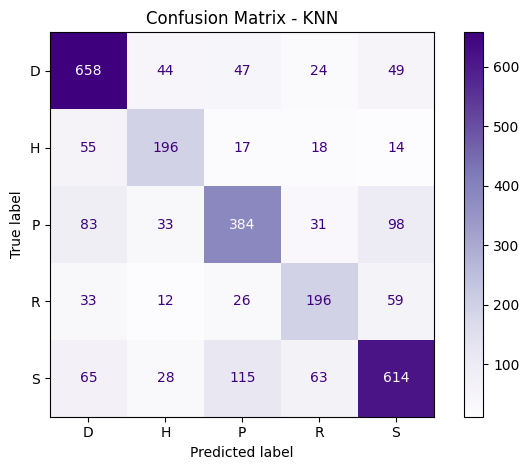

In [146]:
# Evaluate function Has been defined in the Start of the section
evaluate('KNN', y_test, knn_search.best_estimator_.predict(X_test), knn_search.best_estimator_.predict_proba(X_test))

## Model 2: Support Vector Machine (RBF Kernel)

### Model Training

In [147]:
print("=== Hyperparameter Tuning: SVM (RBF) ===\n")
svm_model = OneVsRestClassifier(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
param_grid = {
    'estimator__C': [0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
}
svm_search = GridSearchCV(svm_model, param_grid, cv=3, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
svm_search.fit(X_train, y_train)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print(f"{'Rank':<6} {'C':<8} {'gamma':<12} {'CV Bal. Acc'}")
print("-" * 42)
res = sorted(zip(svm_search.cv_results_['rank_test_score'],
                 svm_search.cv_results_['mean_test_score'],
                 svm_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"{rank:<6} {str(p['estimator__C']):<8} {str(p['estimator__gamma']):<12} {score:.4f}")

=== Hyperparameter Tuning: SVM (RBF) ===

Fitting 3 folds for each of 64 candidates, totalling 192 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
Rank   C        gamma        CV Bal. Acc
------------------------------------------
1      100      scale        0.4924
2      50       scale        0.4892
3      10       scale        0.4750
4      5        scale        0.4641
5      1        scale        0.4278
6      0.5      scale        0.4095
7      0.1      scale        0.3711
8      0.01     scale        0.3661
9      100      1.0          0.3311
10     50       1.0          0.3280


### Evaluation


=== Evaluation Metrics: SVM (RBF) ===

Balanced Accuracy: 0.5144  Macro AUC: 0.8063  Micro AUC: 0.8356
              precision    recall  f1-score   support

           D       0.57      0.87      0.69       822
           H       0.50      0.19      0.28       300
           P       0.56      0.48      0.51       629
           R       0.58      0.44      0.50       326
           S       0.66      0.58      0.62       885

    accuracy                           0.59      2962
   macro avg       0.57      0.51      0.52      2962
weighted avg       0.59      0.59      0.57      2962



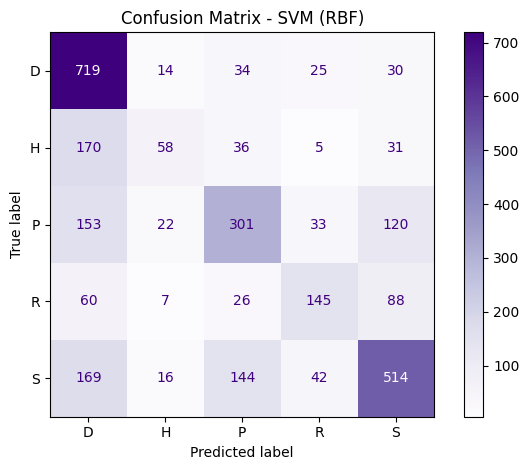

In [148]:
evaluate('SVM (RBF)', y_test, svm_search.best_estimator_.predict(X_test), svm_search.best_estimator_.predict_proba(X_test))

## Model 3: Gradient Boosting

### Model Training

In [149]:
print("=== Hyperparameter Tuning: Gradient Boosting ===\n")
gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0]
}
gb_search = GridSearchCV(gb_model, param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                         scoring='balanced_accuracy', n_jobs=-1, verbose=1)
gb_search.fit(X_train, y_train)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print("-" * 60)
res = sorted(zip(gb_search.cv_results_['rank_test_score'],
                 gb_search.cv_results_['mean_test_score'],
                 gb_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"Rank {rank} | CV Bal. Acc: {score:.4f} | n_estimators={p['n_estimators']}, "
          f"lr={p['learning_rate']}, max_depth={p['max_depth']}, subsample={p['subsample']}")

=== Hyperparameter Tuning: Gradient Boosting ===

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
------------------------------------------------------------
Rank 1 | CV Bal. Acc: 0.5881 | n_estimators=200, lr=0.1, max_depth=7, subsample=0.6
Rank 2 | CV Bal. Acc: 0.5865 | n_estimators=200, lr=0.2, max_depth=7, subsample=0.6
Rank 3 | CV Bal. Acc: 0.5813 | n_estimators=200, lr=0.2, max_depth=7, subsample=0.8
Rank 4 | CV Bal. Acc: 0.5804 | n_estimators=200, lr=0.2, max_depth=7, subsample=1.0
Rank 5 | CV Bal. Acc: 0.5803 | n_estimators=200, lr=0.1, max_depth=7, subsample=0.8
Rank 6 | CV Bal. Acc: 0.5782 | n_estimators=100, lr=0.1, max_depth=7, subsample=0.6
Rank 7 | CV Bal. Acc: 0.5778 | n_estimators=200, lr=0.05, max_depth=7, subsample=0.8
Rank 8 | CV Bal. Acc: 0.5731 | n_estimators=200, lr=0.1, max_depth=7, subsample=1.0
Rank 9 | CV Bal. Acc: 0.5718 | n_estimators=100, lr=0.2, max_depth=7, subsample=1.0
Rank 10

### Evaluation


=== Evaluation Metrics: Gradient Boosting ===

Balanced Accuracy: 0.6109  Macro AUC: 0.8920  Micro AUC: 0.9044
              precision    recall  f1-score   support

           D       0.72      0.86      0.78       822
           H       0.68      0.45      0.54       300
           P       0.65      0.56      0.60       629
           R       0.66      0.44      0.52       326
           S       0.65      0.75      0.70       885

    accuracy                           0.67      2962
   macro avg       0.67      0.61      0.63      2962
weighted avg       0.67      0.67      0.67      2962



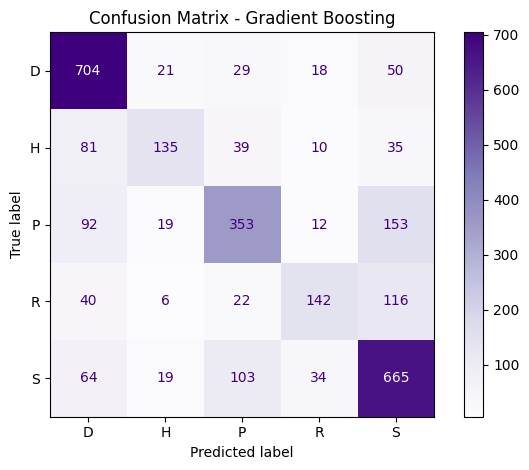

In [150]:
evaluate('Gradient Boosting', y_test, gb_search.best_estimator_.predict(X_test), gb_search.best_estimator_.predict_proba(X_test))

## Model 4: Random Forest

### Model Training

In [151]:
print("=== Hyperparameter Tuning: Random Forest ===\n")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10, 20, 30],
     'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 4, 8],
     'max_features': ['sqrt', 'log2', 0.3, 0.5]},
    n_iter=40, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
rf_search.fit(X_train, y_train)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print("-" * 60)
res = sorted(zip(rf_search.cv_results_['rank_test_score'],
                 rf_search.cv_results_['mean_test_score'],
                 rf_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"Rank {rank} | CV Bal. Acc: {score:.4f} | n_estimators={p['n_estimators']}, "
          f"max_depth={p['max_depth']}, min_samples_split={p['min_samples_split']}, "
          f"min_samples_leaf={p['min_samples_leaf']}, max_features={p['max_features']}")

=== Hyperparameter Tuning: Random Forest ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
------------------------------------------------------------
Rank 1 | CV Bal. Acc: 0.5678 | n_estimators=500, max_depth=30, min_samples_split=2, min_samples_leaf=2, max_features=0.5
Rank 2 | CV Bal. Acc: 0.5664 | n_estimators=100, max_depth=30, min_samples_split=5, min_samples_leaf=1, max_features=0.5
Rank 3 | CV Bal. Acc: 0.5648 | n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=1, max_features=0.3
Rank 4 | CV Bal. Acc: 0.5627 | n_estimators=300, max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features=0.5
Rank 5 | CV Bal. Acc: 0.5607 | n_estimators=100, max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features=0.3
Rank 6 | CV Bal. Acc: 0.5584 | n_estimators=200, max_depth=20, min_samples_split=2, min_samples_leaf=2, max_features=0.3
Rank 7 | CV Bal. Acc: 0.5536 | n_estimato

### Evaluation


=== Evaluation Metrics: Random Forest ===

Balanced Accuracy: 0.5929  Macro AUC: 0.8935  Micro AUC: 0.9034
              precision    recall  f1-score   support

           D       0.67      0.87      0.76       822
           H       0.83      0.37      0.51       300
           P       0.68      0.51      0.58       629
           R       0.65      0.45      0.53       326
           S       0.64      0.77      0.70       885

    accuracy                           0.67      2962
   macro avg       0.69      0.59      0.62      2962
weighted avg       0.68      0.67      0.65      2962



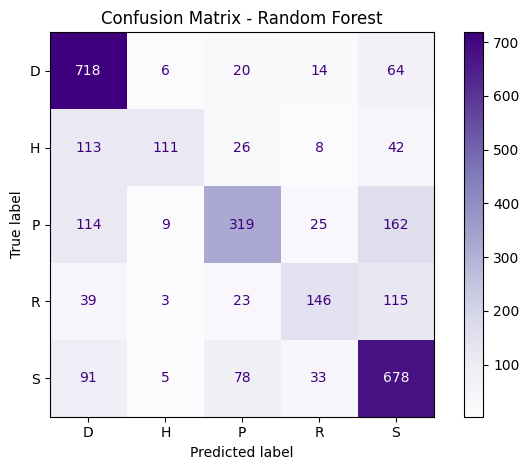

In [152]:
evaluate('Random Forest', y_test, rf_search.best_estimator_.predict(X_test), rf_search.best_estimator_.predict_proba(X_test))

## Model 5: LightGBM

### Model Training

In [153]:
print("=== Hyperparameter Tuning: LightGBM ===\n")
lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    {'n_estimators': [50, 100, 200, 300, 500], 'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
     'num_leaves': [15, 31, 63, 127], 'max_depth': [-1, 3, 5, 7, 10],
     'min_child_samples': [10, 20, 30, 50],
     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]},
    n_iter=40, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
lgbm_search.fit(X_train, y_train)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print("-" * 60)
res = sorted(zip(lgbm_search.cv_results_['rank_test_score'],
                 lgbm_search.cv_results_['mean_test_score'],
                 lgbm_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"Rank {rank} | CV Bal. Acc: {score:.4f} | n_estimators={p['n_estimators']}, "
          f"lr={p['learning_rate']}, num_leaves={p['num_leaves']}, max_depth={p['max_depth']}, "
          f"min_child_samples={p['min_child_samples']}, subsample={p['subsample']}, colsample={p['colsample_bytree']}")

=== Hyperparameter Tuning: LightGBM ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
------------------------------------------------------------
Rank 1 | CV Bal. Acc: 0.6228 | n_estimators=500, lr=0.2, num_leaves=127, max_depth=-1, min_child_samples=50, subsample=0.7, colsample=0.6
Rank 2 | CV Bal. Acc: 0.6228 | n_estimators=500, lr=0.1, num_leaves=127, max_depth=10, min_child_samples=20, subsample=0.6, colsample=0.7
Rank 3 | CV Bal. Acc: 0.6223 | n_estimators=200, lr=0.3, num_leaves=127, max_depth=-1, min_child_samples=20, subsample=0.9, colsample=0.9
Rank 4 | CV Bal. Acc: 0.6114 | n_estimators=300, lr=0.3, num_leaves=31, max_depth=10, min_child_samples=20, subsample=1.0, colsample=0.7
Rank 5 | CV Bal. Acc: 0.6080 | n_estimators=300, lr=0.1, num_leaves=63, max_depth=10, min_child_samples=20, subsample=0.9, colsample=0.9
Rank 6 | CV Bal. Acc: 0.6073 | n_estimators=500, lr=0.05, num_leaves=63, max_depth=10,

### Evaluation


=== Evaluation Metrics: LightGBM ===

Balanced Accuracy: 0.6549  Macro AUC: 0.9101  Micro AUC: 0.9199
              precision    recall  f1-score   support

           D       0.74      0.87      0.80       822
           H       0.71      0.54      0.61       300
           P       0.69      0.58      0.63       629
           R       0.63      0.52      0.57       326
           S       0.70      0.77      0.73       885

    accuracy                           0.71      2962
   macro avg       0.69      0.65      0.67      2962
weighted avg       0.70      0.71      0.70      2962



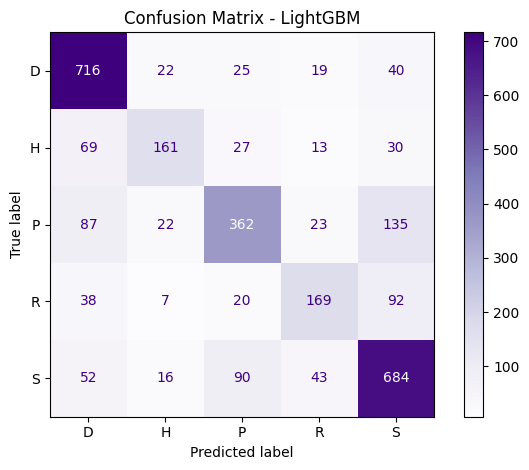

In [154]:
evaluate('LightGBM', y_test, lgbm_search.best_estimator_.predict(X_test), lgbm_search.best_estimator_.predict_proba(X_test))

## Model 6: XGBoost

### Model Training

In [155]:
print("=== Hyperparameter Tuning: XGBoost ===\n")
le = LabelEncoder()
y_train_enc, y_test_enc = le.fit_transform(y_train), le.transform(y_test)

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_search = GridSearchCV(
    XGBClassifier(objective='multi:softprob', use_label_encoder=False, eval_metric='mlogloss',
                  random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train_enc)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print("-" * 60)
res = sorted(zip(xgb_search.cv_results_['rank_test_score'],
                 xgb_search.cv_results_['mean_test_score'],
                 xgb_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"Rank {rank} | CV Bal. Acc: {score:.4f} | n_estimators={p['n_estimators']}, "
          f"lr={p['learning_rate']}, max_depth={p['max_depth']}, "
          f"subsample={p['subsample']}, colsample={p['colsample_bytree']}")

=== Hyperparameter Tuning: XGBoost ===

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
------------------------------------------------------------
Rank 1 | CV Bal. Acc: 0.6042 | n_estimators=200, lr=0.2, max_depth=7, subsample=0.8, colsample=1.0
Rank 2 | CV Bal. Acc: 0.6031 | n_estimators=200, lr=0.2, max_depth=7, subsample=0.8, colsample=0.8
Rank 3 | CV Bal. Acc: 0.6019 | n_estimators=200, lr=0.2, max_depth=7, subsample=0.6, colsample=1.0
Rank 4 | CV Bal. Acc: 0.6007 | n_estimators=200, lr=0.2, max_depth=7, subsample=0.6, colsample=0.8
Rank 5 | CV Bal. Acc: 0.6004 | n_estimators=200, lr=0.2, max_depth=7, subsample=0.8, colsample=0.6
Rank 6 | CV Bal. Acc: 0.5990 | n_estimators=200, lr=0.2, max_depth=7, subsample=1.0, colsample=1.0
Rank 7 | CV Bal. Acc: 0.5989 | n_estimators=200, lr=0.2, max_depth=7, subsample=1.0, colsample=0.8
Rank 8 | CV Bal. Acc: 0.5980 | n_estimators=200, lr=0.2, max_depth=7, subsample=

### Evaluation


=== Evaluation Metrics: XGBoost ===

Balanced Accuracy: 0.6395  Macro AUC: 0.9047  Micro AUC: 0.9156
              precision    recall  f1-score   support

           D       0.73      0.86      0.79       822
           H       0.74      0.50      0.60       300
           P       0.68      0.57      0.62       629
           R       0.67      0.48      0.56       326
           S       0.67      0.79      0.72       885

    accuracy                           0.70      2962
   macro avg       0.70      0.64      0.66      2962
weighted avg       0.70      0.70      0.69      2962



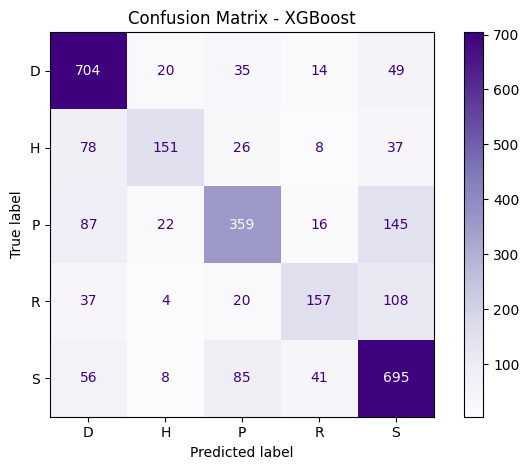

In [156]:
evaluate('XGBoost', y_test, le.inverse_transform(xgb_search.predict(X_test)), xgb_search.predict_proba(X_test))

## Model 7: Extra Trees

### Model Training

In [157]:
print("=== Hyperparameter Tuning: Extra Trees ===\n")
et_model = ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1)
param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5]
}
et_search = RandomizedSearchCV(et_model, param_distributions=param_dist, n_iter=40,
                               cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                               scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
et_search.fit(X_train, y_train)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print("-" * 60)
res = sorted(zip(et_search.cv_results_['rank_test_score'],
                 et_search.cv_results_['mean_test_score'],
                 et_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"Rank {rank} | CV Bal. Acc: {score:.4f} | n_estimators={p['n_estimators']}, "
          f"max_depth={p['max_depth']}, min_samples_split={p['min_samples_split']}, "
          f"min_samples_leaf={p['min_samples_leaf']}, max_features={p['max_features']}")

=== Hyperparameter Tuning: Extra Trees ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
------------------------------------------------------------
Rank 1 | CV Bal. Acc: 0.5819 | n_estimators=500, max_depth=30, min_samples_split=2, min_samples_leaf=2, max_features=0.5
Rank 2 | CV Bal. Acc: 0.5811 | n_estimators=100, max_depth=30, min_samples_split=5, min_samples_leaf=1, max_features=0.5
Rank 3 | CV Bal. Acc: 0.5803 | n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=1, max_features=0.3
Rank 4 | CV Bal. Acc: 0.5756 | n_estimators=300, max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features=0.5
Rank 5 | CV Bal. Acc: 0.5566 | n_estimators=100, max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features=0.3
Rank 6 | CV Bal. Acc: 0.5459 | n_estimators=300, max_depth=None, min_samples_split=10, min_samples_leaf=1, max_features=0.3
Rank 7 | CV Bal. Acc: 0.5349 | n_estimat

### Evaluation


=== Evaluation Metrics: Extra Trees ===

Balanced Accuracy: 0.6096  Macro AUC: 0.9063  Micro AUC: 0.9130
              precision    recall  f1-score   support

           D       0.69      0.89      0.78       822
           H       0.92      0.40      0.56       300
           P       0.70      0.52      0.60       629
           R       0.72      0.43      0.54       326
           S       0.64      0.80      0.71       885

    accuracy                           0.69      2962
   macro avg       0.73      0.61      0.64      2962
weighted avg       0.70      0.69      0.67      2962



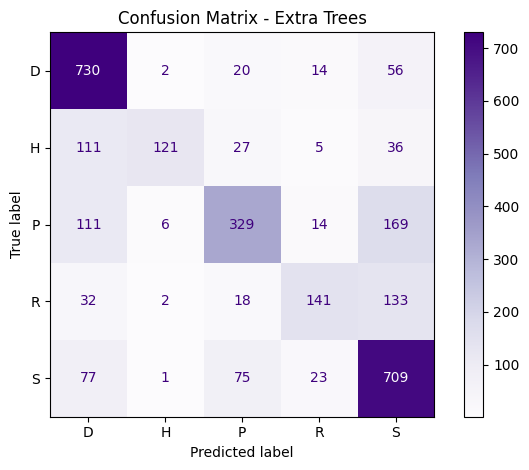

In [158]:
evaluate('Extra Trees', y_test, et_search.best_estimator_.predict(X_test), et_search.best_estimator_.predict_proba(X_test))

## Model 8: Multi-Layer Perceptron

### Model Training

In [159]:
print("=== Hyperparameter Tuning: MLP ===\n")
mlp_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', MLPClassifier(max_iter=500, random_state=RANDOM_STATE))]),
    {'clf__hidden_layer_sizes': [(64,), (128,), (256,), (64, 64), (128, 64),
                                  (128, 128), (256, 128), (64, 64, 32)],
     'clf__activation': ['relu', 'tanh'],
     'clf__alpha': [1e-5, 1e-4, 1e-3, 0.01, 0.1],
     'clf__learning_rate': ['constant', 'adaptive']},
    n_iter=30, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
mlp_search.fit(X_train, y_train)

print("\nTop 10 Hyperparameter Combinations (by CV Balanced Accuracy):")
print("-" * 60)
res = sorted(zip(mlp_search.cv_results_['rank_test_score'],
                 mlp_search.cv_results_['mean_test_score'],
                 mlp_search.cv_results_['params']), key=lambda x: x[0])
for rank, score, p in res[:10]:
    print(f"Rank {rank} | CV Bal. Acc: {score:.4f} | layers={p['clf__hidden_layer_sizes']}, "
          f"activation={p['clf__activation']}, alpha={p['clf__alpha']}, lr={p['clf__learning_rate']}")

=== Hyperparameter Tuning: MLP ===

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Top 5 Hyperparameter Combinations (by CV Balanced Accuracy):
------------------------------------------------------------
Rank 1 | CV Bal. Acc: 0.5324 | layers=(256, 128), activation=tanh, alpha=0.01, lr=adaptive
Rank 2 | CV Bal. Acc: 0.5297 | layers=(256, 128), activation=tanh, alpha=0.0001, lr=constant
Rank 3 | CV Bal. Acc: 0.5269 | layers=(256, 128), activation=relu, alpha=1e-05, lr=constant
Rank 4 | CV Bal. Acc: 0.5250 | layers=(256, 128), activation=relu, alpha=0.0001, lr=adaptive
Rank 5 | CV Bal. Acc: 0.5192 | layers=(128, 64), activation=relu, alpha=0.01, lr=constant
Rank 6 | CV Bal. Acc: 0.5081 | layers=(128, 128), activation=relu, alpha=0.1, lr=adaptive
Rank 7 | CV Bal. Acc: 0.5078 | layers=(128, 64), activation=relu, alpha=1e-05, lr=adaptive
Rank 8 | CV Bal. Acc: 0.5052 | layers=(128, 64), activation=relu, alpha=0.0001, lr=constant
Rank 9 | CV Bal. Acc: 0.5051 | layers=(128, 64),

### Evaluation


=== Evaluation Metrics: MLP ===

Balanced Accuracy: 0.5677  Macro AUC: 0.8123  Micro AUC: 0.8298
              precision    recall  f1-score   support

           D       0.68      0.76      0.72       822
           H       0.52      0.49      0.51       300
           P       0.52      0.51      0.51       629
           R       0.50      0.49      0.49       326
           S       0.64      0.59      0.61       885

    accuracy                           0.60      2962
   macro avg       0.57      0.57      0.57      2962
weighted avg       0.60      0.60      0.60      2962



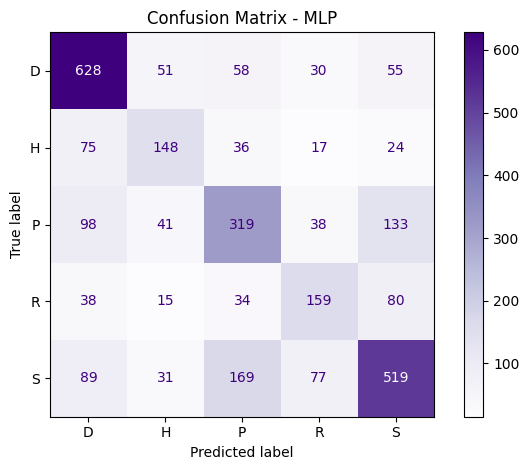

In [160]:
evaluate('MLP', y_test, mlp_search.best_estimator_.predict(X_test), mlp_search.best_estimator_.predict_proba(X_test))

# Final Comparison

## ROC Comparison per Class
For each class, a separate graph is plotted showing the One-vs-Rest ROC curves of all classification methods, making it easy to compare their performance.

                   Bal. Acc  Macro AUC  Micro AUC
LightGBM             0.6549     0.9101     0.9199
Extra Trees          0.6096     0.9063     0.9130
XGBoost              0.6395     0.9047     0.9156
Random Forest        0.5929     0.8935     0.9034
Gradient Boosting    0.6109     0.8920     0.9044
MLP                  0.5677     0.8123     0.8298
SVM (RBF)            0.5144     0.8063     0.8356
KNN                  0.6719     0.7960     0.8071


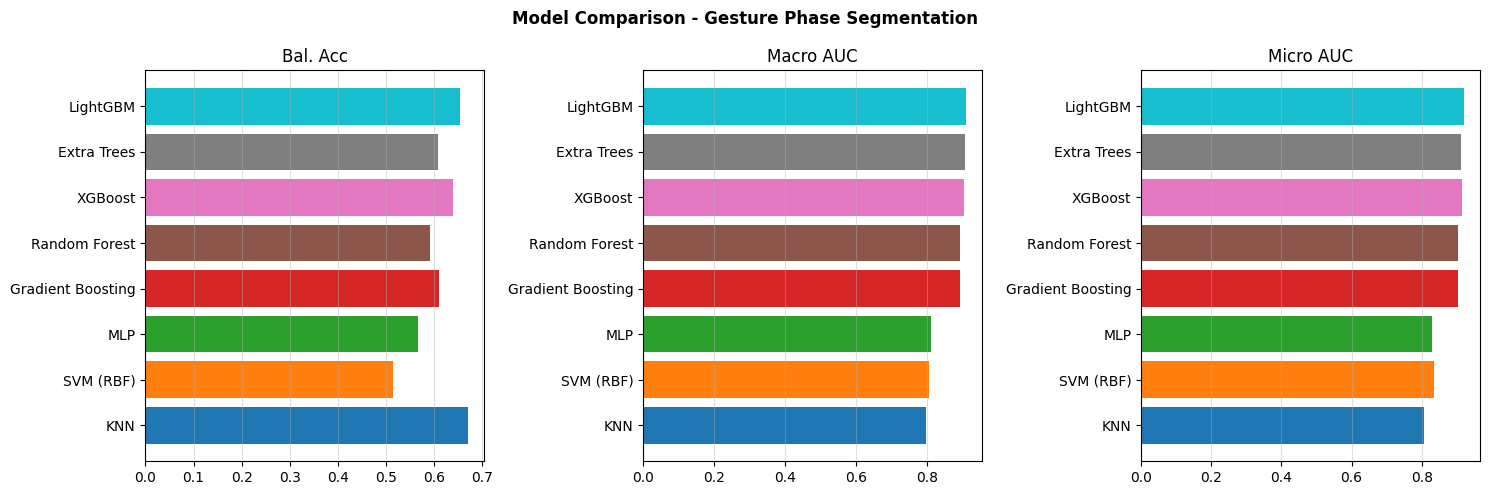

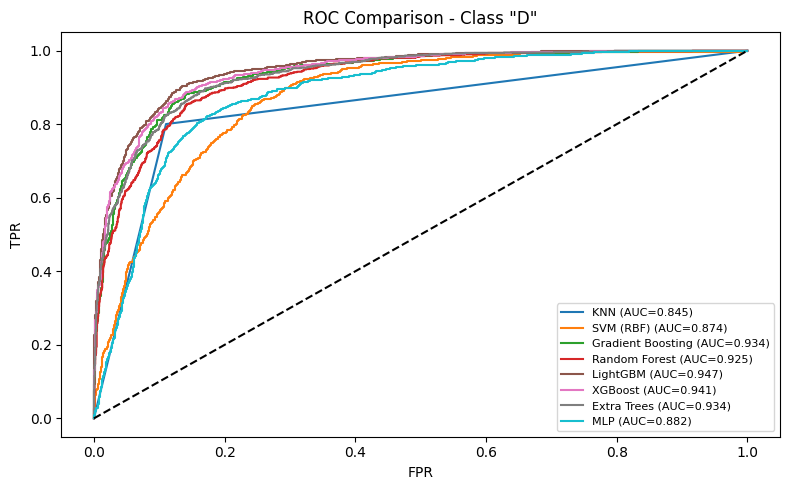

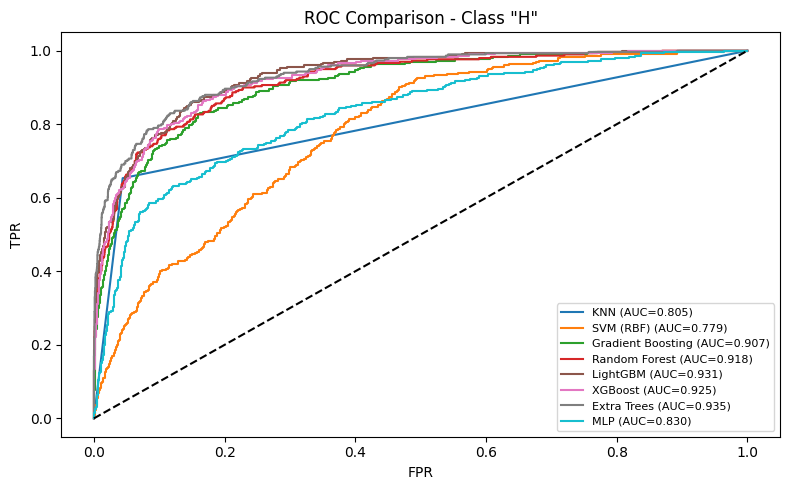

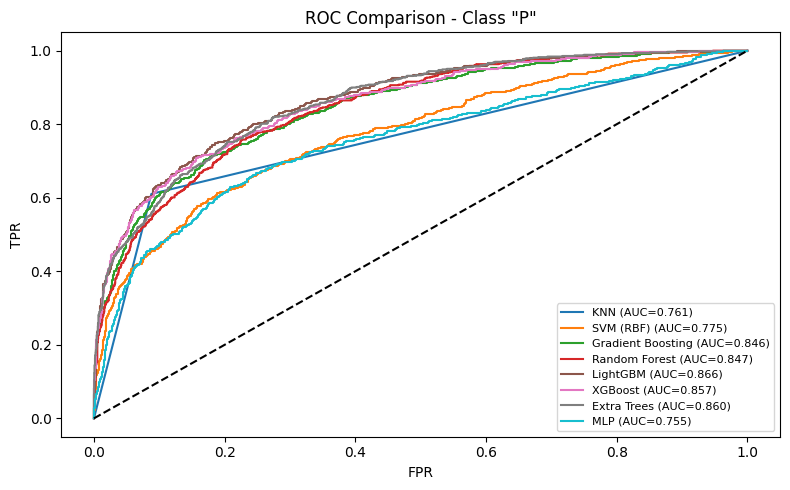

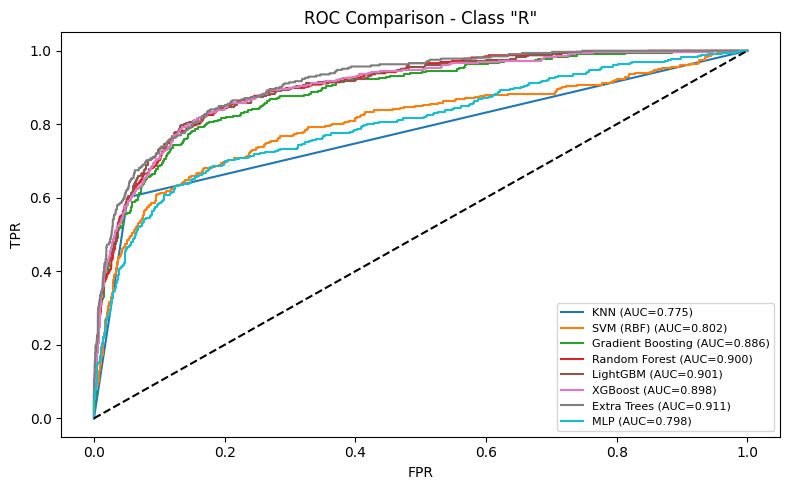

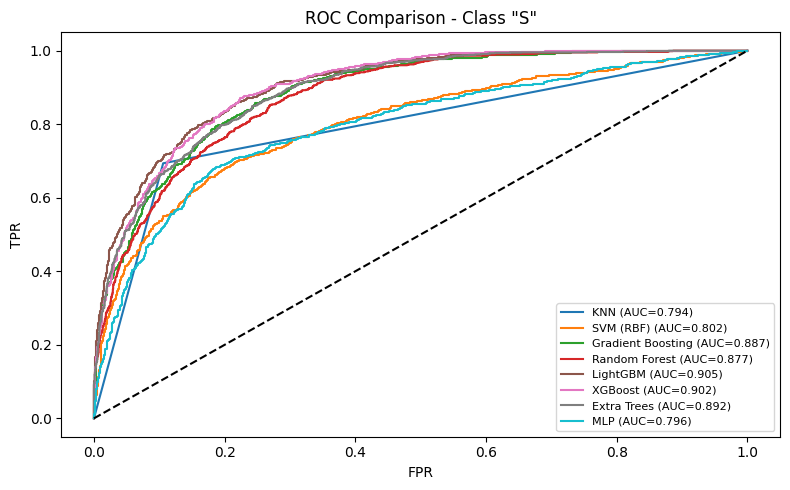

In [166]:
summary = pd.DataFrame(all_results).T
summary.columns = ['Bal. Acc', 'Macro AUC', 'Micro AUC']
summary = summary.sort_values('Macro AUC', ascending=False)
print(summary.round(4).to_string())

colors = plt.cm.tab10(np.linspace(0, 0.9, len(summary)))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Bal. Acc', 'Macro AUC', 'Micro AUC']):
    ax.barh(summary.index[::-1], summary[col][::-1], color=colors)
    ax.set_title(col); ax.grid(axis='x', alpha=0.4)
plt.suptitle('Model Comparison - Gesture Phase Segmentation', fontweight='bold')
plt.tight_layout(); plt.show()

plot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_roc_data)))
for cls in CLASSES:
    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, data), color in zip(all_roc_data.items(), plot_colors):
        ax.plot(data['fpr'][cls], data['tpr'][cls], color=color,
                label=f'{name} (AUC={data["auc"][cls]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Comparison - Class "{cls}"')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()

**Bar charts (Balanced Accuracy, Macro AUC, Micro AUC):** Gradient boosting-based and tree ensemble methods rank consistently higher across all three metrics, confirming that non-linear, ensemble-based approaches are better suited to the complexity of gesture phase segmentation than linear or distance-based classifiers. The close agreement in ranking between balanced accuracy and macro AUC indicates that the evaluation metrics are well-aligned for this dataset.

**Per-class OvR ROC curves:** Performance varies noticeably across the five gesture phases — the Hold (H) and Retraction (R) classes, being minority classes, tend to show lower AUC values than Stroke (S) and Rest (D), highlighting the impact of class imbalance on per-class separability. Models with more uniformly high AUC across all five classes demonstrate greater robustness to the imbalance in the dataset.

## ROC Comparison: Macro- and Micro-Average (One-vs-Rest)
Each plot overlays all classification methods on a single graph for direct comparison.

#### **Macro-average OvR ROC:**
The macro-average treats all five gesture phases equally, giving the same weight to minority classes (Hold, Retraction) as to majority classes (Stroke, Rest), making it a fairer measure of overall model quality under class imbalance. Models whose curves cluster near the top-left corner with high AUC values demonstrate that they generalise consistently across all gesture phases rather than relying on strong performance only on frequent classes.

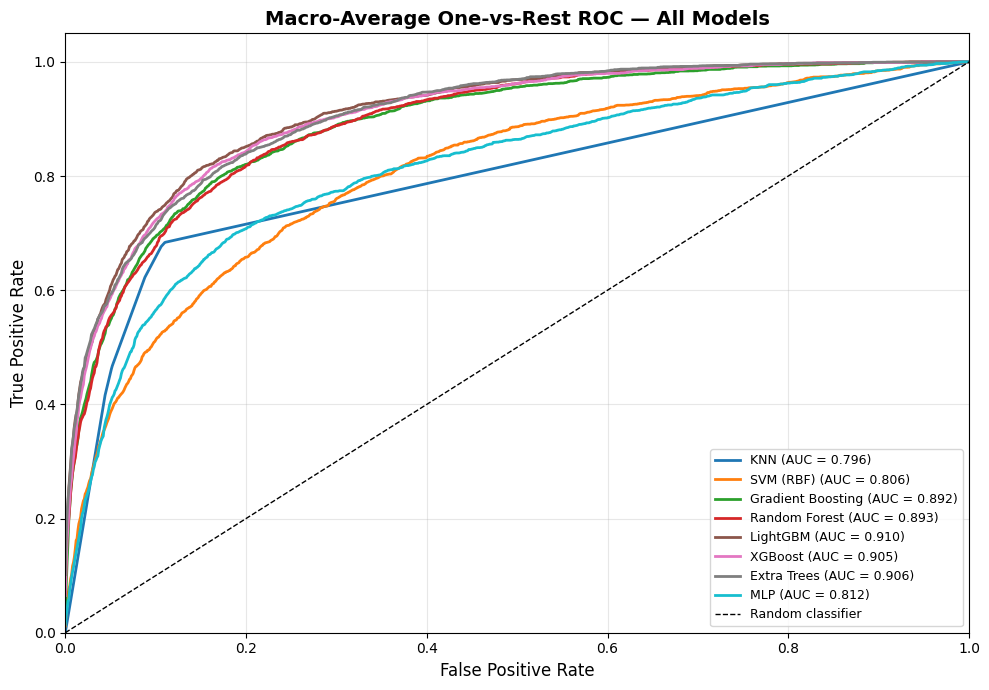

In [162]:
# Macro-average OvR ROC — all models on one graph
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_roc_data)))

for (name, data), color in zip(all_roc_data.items(), colors):
    macro_auc = all_results[name]['macro_auc']
    ax.plot(data['fpr']['macro'], data['tpr']['macro'], color=color, lw=2,
            label=f'{name} (AUC = {macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Macro-Average One-vs-Rest ROC — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### **Micro-average OvR ROC:** 
The micro-average aggregates predictions across all classes weighted by sample count, so it is dominated by the majority classes (Stroke and Rest). Models whose micro-average AUC closely tracks their macro-average AUC demonstrate balanced performance across both frequent and rare gesture phases, whereas a large gap between the two would signal that a model is performing well on common classes but failing on minority ones.

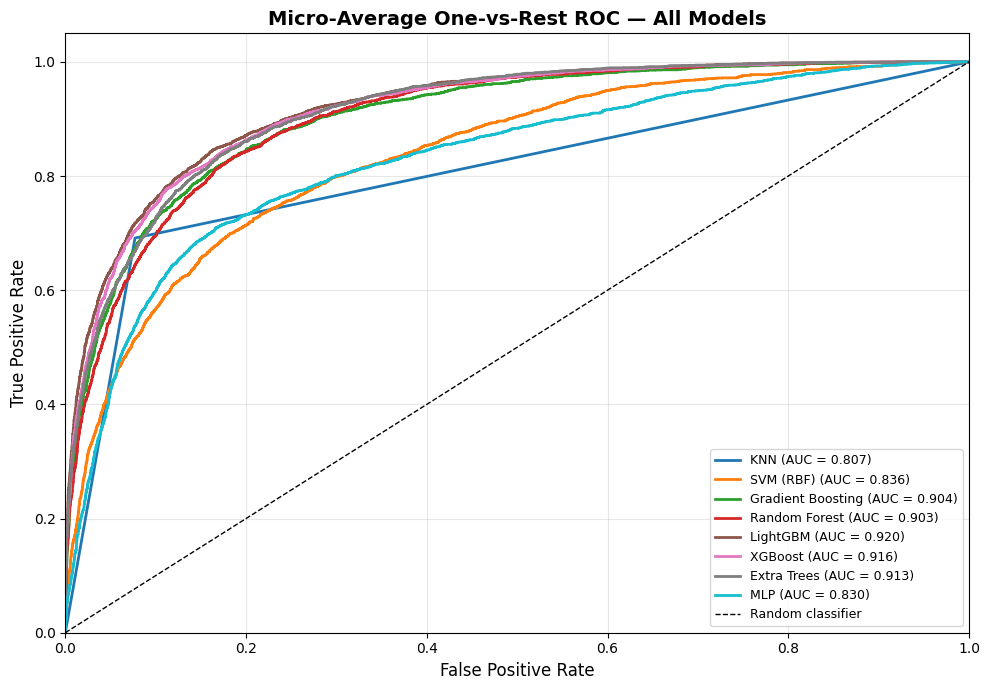

In [163]:
# Micro-average OvR ROC — all models on one graph
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_roc_data)))

for (name, data), color in zip(all_roc_data.items(), colors):
    micro_auc = all_results[name]['micro_auc']
    ax.plot(data['fpr']['micro'], data['tpr']['micro'], color=color, lw=2,
            label=f'{name} (AUC = {micro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Micro-Average One-vs-Rest ROC — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Conclusion

- Tree-based ensemble methods (LightGBM, XGBoost, Gradient Boosting, Random Forest, Extra Trees) consistently outperform distance-based and linear methods on this dataset, confirming that the gesture phase feature space contains non-linear interactions that simpler models cannot capture effectively.

- Class imbalance between the minority gesture phases (Hold, Retraction) and the majority phases (Stroke, Rest) is reflected across all models. Balanced accuracy and macro AUC are therefore more informative evaluation metrics than raw accuracy or micro AUC alone for this task.

- The close alignment between balanced accuracy rankings and macro AUC rankings across all models indicates that the chosen evaluation metrics are mutually consistent, strengthening confidence in the comparative conclusions drawn from the results.

- Hyperparameter tuning via cross-validated search (GridSearchCV / RandomizedSearchCV) had a measurable impact on model performance, with the top-ranked parameter combinations achieving meaningfully higher CV balanced accuracy than the default configurations, justifying the computational cost of the search.

- Based on the highest balanced accuracy and macro AUC achieved across all experiments, **LightGBM** is recommended as the preferred method for this gesture phase segmentation task.

# References

### 1. K-Nearest Neighbours (KNN)
- **Theory:** Cover, T. & Hart, P. (1967). *Nearest Neighbor Pattern Classification.* IEEE Transactions on Information Theory. [https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)
- **Implementation:** scikit-learn. *KNeighborsClassifier API.* [https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

### 2. Gradient Boosting
- **Theory:** Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* Annals of Statistics. [https://en.wikipedia.org/wiki/Gradient_boosting](https://en.wikipedia.org/wiki/Gradient_boosting)
- **Implementation:** scikit-learn. *GradientBoostingClassifier API.* [https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

### 3. XGBoost
- **Theory:** Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* KDD 2016. [https://arxiv.org/abs/1603.02754](https://arxiv.org/abs/1603.02754)
- **Implementation:** XGBoost Developers. *XGBoost Python API.* [https://xgboost.readthedocs.io/en/stable/python/python_api.html](https://xgboost.readthedocs.io/en/stable/python/python_api.html)

### 4. Random Forest
- **Theory:** Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5–32. [https://en.wikipedia.org/wiki/Random_forest](https://en.wikipedia.org/wiki/Random_forest)
- **Implementation:** scikit-learn. *RandomForestClassifier API.* [https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

### 5. Extra Trees
- **Theory:** Geurts, P., Ernst, D. & Wehenkel, L. (2006). *Extremely Randomized Trees.* Machine Learning, 63(1), 3–42. [https://en.wikipedia.org/wiki/Random_forest#ExtraTrees](https://en.wikipedia.org/wiki/Random_forest#ExtraTrees)
- **Implementation:** scikit-learn. *ExtraTreesClassifier API.* [https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html)

### 6. Multi-Layer Perceptron (MLP)
- **Theory:** Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning.* MIT Press. [https://en.wikipedia.org/wiki/Multilayer_perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron)
- **Implementation:** scikit-learn. *MLPClassifier API.* [https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

### 7. LightGBM
- **Theory:** Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* NeurIPS. [https://lightgbm.readthedocs.io/en/stable/Features.html](https://lightgbm.readthedocs.io/en/stable/Features.html)
- **Implementation:** LightGBM Developers. *LGBMClassifier API.* [https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMClassifier.html](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMClassifier.html)

### 8. Support Vector Machine (SVM)
- **Theory:** Cortes, C. & Vapnik, V. (1995). *Support-Vector Networks.* Machine Learning, 20(3), 273–297. [https://en.wikipedia.org/wiki/Support_vector_machine](https://en.wikipedia.org/wiki/Support_vector_machine)
- **Implementation:** scikit-learn. *SVC API.* [https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

---

## Evaluation Metrics References

- **Balanced Accuracy:** Brodersen, K. H. et al. (2010). *The Balanced Accuracy and Its Posterior Distribution.* ICPR. scikit-learn docs: [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html)
- **ROC AUC (Macro & Micro):** Fawcett, T. (2006). *An Introduction to ROC Analysis.* Pattern Recognition Letters, 27(8), 861–874. scikit-learn docs: [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)

# APPENDIX I:

Use of Generative AI


· This submission is my/our own independent work and all sources used in the submission are referenced. Generative AI was NOT USED for this submission.